# 📈 Statistical Analysis — Airbnb NYC 2019

## Problem Statement
Apply statistical methods to validate patterns discovered during EDA, build a predictive model for pricing, and segment listings into meaningful customer clusters.

---

### Notebook Outline
1. Hypothesis Testing (ANOVA, t-test, Correlation)
2. Linear Regression (Price Prediction)
3. KMeans Clustering (Market Segmentation)
4. Final Statistical Insights

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [3]:

df = pd.read_csv('../data/processed/processed_AB_NYC_2019 (5).csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 45923 rows × 16 columns


,id,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_per_person
0,2539,Clean & quiet apt home by the park,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00,0.21,6,365,74.50
1,2595,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00,0.38,2,355,112.50
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365,37.50
3,3831,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05 00:00:00,4.64,1,194,44.50
4,5022,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19 00:00:00,0.10,1,0,7.27


---
## 🔹 Step 1: Hypothesis Testing
We formulate and test three hypotheses using appropriate statistical tests.

### 1.1 — Room Type vs Price (One-Way ANOVA)

| | |
|---|---|
| **H₀** | There is no significant difference in mean price across room types |
| **H₁** | At least one room type has a significantly different mean price |
| **Test** | One-Way ANOVA (α = 0.05) |

In [4]:

groups = [group['price'].values for _, group in df.groupby('room_type')]

f_stat, p_value = stats.f_oneway(*groups)

print(f'F-Statistic : {f_stat:.4f}')
print(f'p-value     : {p_value:.2e}')
print()
if p_value < 0.05:
    print('✅ Result: REJECT H₀ — There IS a significant difference in price across room types.')
else:
    print('❌ Result: FAIL TO REJECT H₀ — No significant difference detected.')

F-Statistic : 14440.9810
p-value     : 0.00e+00

✅ Result: REJECT H₀ — There IS a significant difference in price across room types.


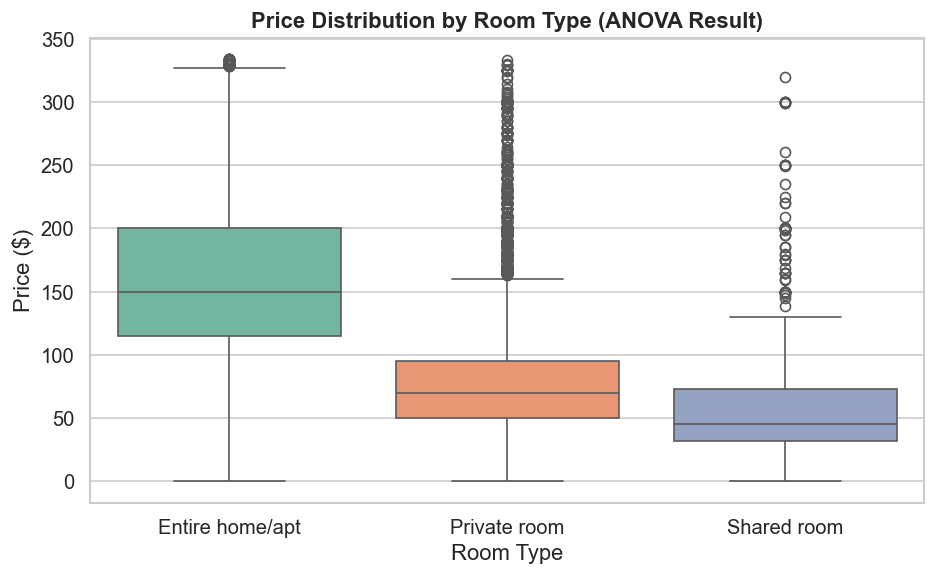

In [5]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['price'] <= 500], x='room_type', y='price',
            palette='Set2', order=['Entire home/apt', 'Private room', 'Shared room'])
plt.title('Price Distribution by Room Type (ANOVA Result)', fontweight='bold')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

### 📝 Insight
Room type is a **statistically significant predictor of price**. Entire homes command the highest prices, followed by private rooms, then shared rooms.

### 1.2 — Manhattan vs Other Boroughs Pricing (Independent t-test)

| | |
|---|---|
| **H₀** | Mean price in Manhattan = Mean price in other boroughs |
| **H₁** | Mean price in Manhattan ≠ Mean price in other boroughs |
| **Test** | Welch's Independent t-test (α = 0.05) |

In [6]:

manhattan = df[df['neighbourhood_group'] == 'Manhattan']['price']
others = df[df['neighbourhood_group'] != 'Manhattan']['price']

t_stat, p_value = stats.ttest_ind(manhattan, others, equal_var=False)

print(f'Manhattan mean price : ${manhattan.mean():.2f}')
print(f'Others mean price    : ${others.mean():.2f}')
print(f't-Statistic          : {t_stat:.4f}')
print(f'p-value              : {p_value:.2e}')
print()
if p_value < 0.05:
    print('✅ Result: REJECT H₀ — Manhattan pricing is significantly different from other boroughs.')
else:
    print('❌ Result: FAIL TO REJECT H₀ — No significant difference detected.')

Manhattan mean price : $145.95
Others mean price    : $100.79
t-Statistic          : 72.4539
p-value              : 0.00e+00

✅ Result: REJECT H₀ — Manhattan pricing is significantly different from other boroughs.


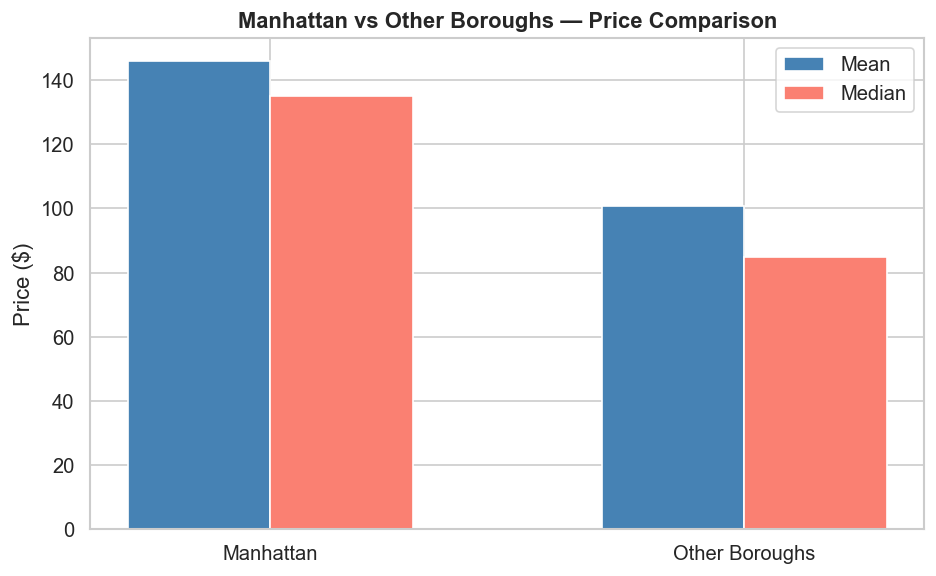

In [7]:

plt.figure(figsize=(8, 5))
labels = ['Manhattan', 'Other Boroughs']
means = [manhattan.mean(), others.mean()]
medians = [manhattan.median(), others.median()]

x = np.arange(len(labels))
width = 0.3

plt.bar(x - width/2, means, width, label='Mean', color='steelblue')
plt.bar(x + width/2, medians, width, label='Median', color='salmon')
plt.xticks(x, labels)
plt.ylabel('Price ($)')
plt.title('Manhattan vs Other Boroughs — Price Comparison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 📝 Insight
Manhattan listings are **significantly more expensive** than the rest of NYC. This confirms the borough premium observed in EDA.

### 1.3 — Reviews vs Availability (Pearson Correlation Test)

| | |
|---|---|
| **H₀** | No significant correlation between number of reviews and availability |
| **H₁** | A significant correlation exists |
| **Test** | Pearson Correlation (α = 0.05) |

In [8]:

corr_coef, p_value = stats.pearsonr(df['number_of_reviews'], df['availability_365'])

print(f'Pearson r   : {corr_coef:.4f}')
print(f'p-value     : {p_value:.2e}')
print()
if p_value < 0.05:
    strength = 'weak' if abs(corr_coef) < 0.3 else 'moderate' if abs(corr_coef) < 0.7 else 'strong'
    direction = 'positive' if corr_coef > 0 else 'negative'
    print(f'✅ Result: REJECT H₀ — A {strength} {direction} correlation exists (r = {corr_coef:.4f}).')
else:
    print('❌ Result: FAIL TO REJECT H₀ — No significant correlation detected.')

Pearson r   : 0.1836
p-value     : 0.00e+00

✅ Result: REJECT H₀ — A weak positive correlation exists (r = 0.1836).


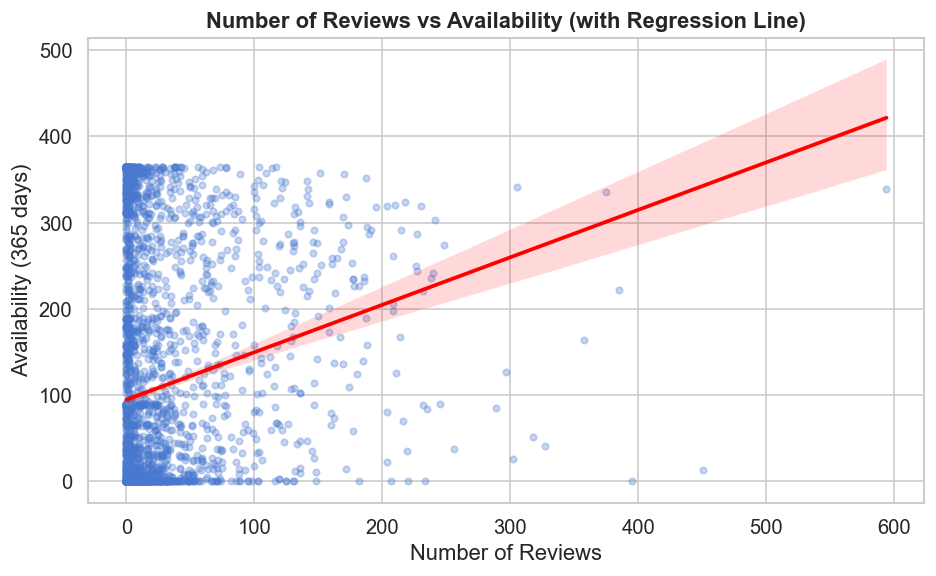

In [9]:

plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(3000, random_state=42),
            x='number_of_reviews', y='availability_365',
            scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
plt.title('Number of Reviews vs Availability (with Regression Line)', fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Availability (365 days)')
plt.tight_layout()
plt.show()

### 📝 Insight
The correlation between reviews and availability is statistically significant but **weak in magnitude** — availability is influenced by many factors beyond just review count.

---
## 🔹 Step 2: Linear Regression — Price Prediction

**Goal:** Build a simple linear regression model to predict listing price from numerical features and evaluate its performance.

In [10]:

features = ['number_of_reviews', 'availability_365', 'minimum_nights', 'reviews_per_month']

reg_df = df[features + ['price']].dropna()
print(f'Regression dataset: {reg_df.shape[0]} rows')

X = reg_df[features]
y = reg_df['price']

Regression dataset: 45923 rows


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set    : {X_test.shape[0]} samples')

Training set: 36738 samples
Test set    : 9185 samples


In [12]:

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('═══ Model Performance ═══')
print(f'R² Score : {r2:.4f}')
print(f'MAE      : ${mae:.2f}')
print(f'MSE      : {mse:.2f}')
print(f'RMSE     : ${rmse:.2f}')

═══ Model Performance ═══
R² Score : 0.0059
MAE      : $55.02
MSE      : 4630.56
RMSE     : $68.05


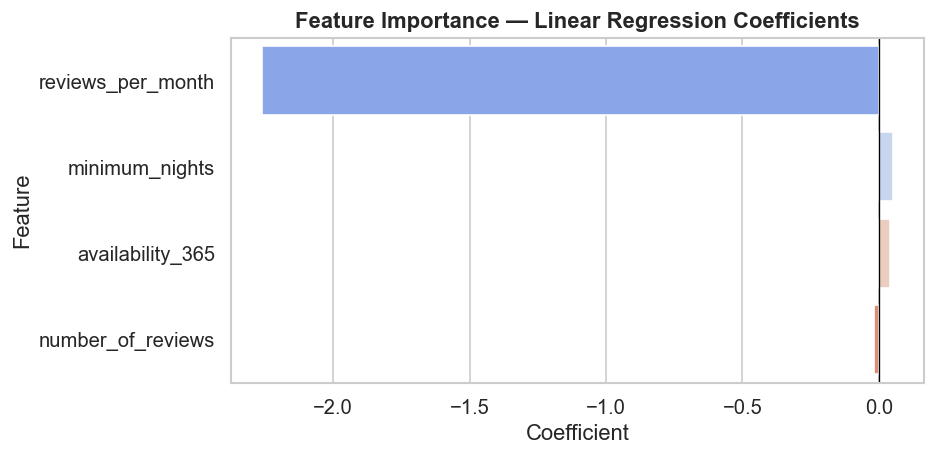

,Feature,Coefficient
3,reviews_per_month,-2.259939
2,minimum_nights,0.051974
1,availability_365,0.040108
0,number_of_reviews,-0.019075


In [13]:

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Importance — Linear Regression Coefficients', fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df

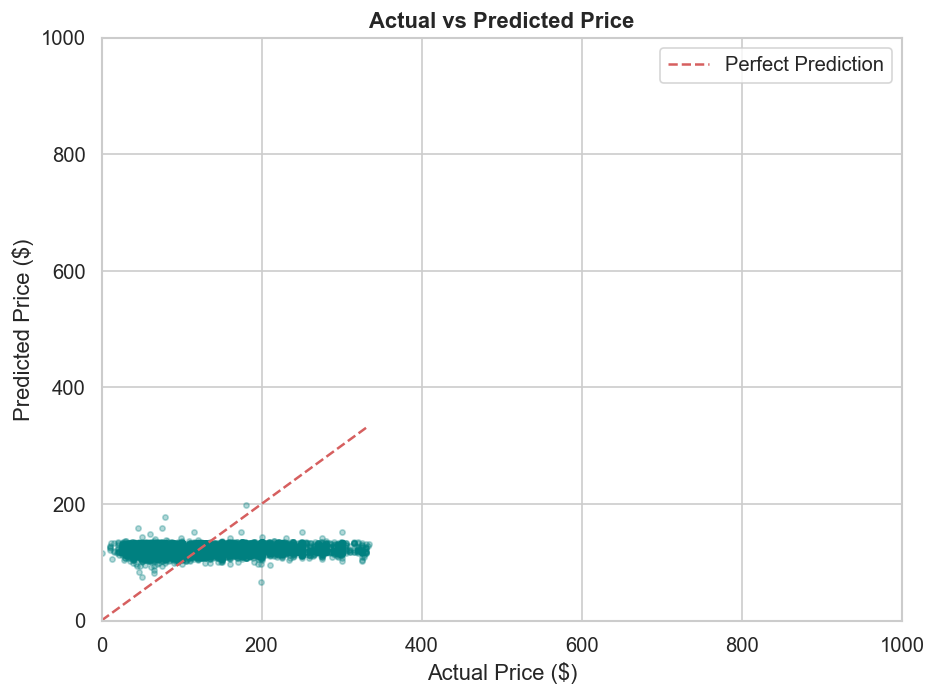

In [14]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='teal')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Price', fontweight='bold')
plt.legend()
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()

### 📝 Insights — Linear Regression
- The R² score is **low**, indicating that these numerical features alone are poor predictors of price.
- This confirms our EDA finding: **room type and location are the dominant pricing factors**, not review count or availability.
- Among the numerical features, `minimum_nights` and `reviews_per_month` have the largest (though still small) impact.
- A more powerful model would need to encode `room_type` and `neighbourhood_group` as features.

---
## 🔹 Step 3: Segmentation — KMeans Clustering

**Goal:** Identify natural market segments among listings using unsupervised clustering.

In [15]:

cluster_features = ['price', 'availability_365', 'number_of_reviews']
cluster_df = df[cluster_features].dropna()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

print(f'Clustering dataset: {cluster_df.shape[0]} samples, {cluster_df.shape[1]} features')

Clustering dataset: 45923 samples, 3 features


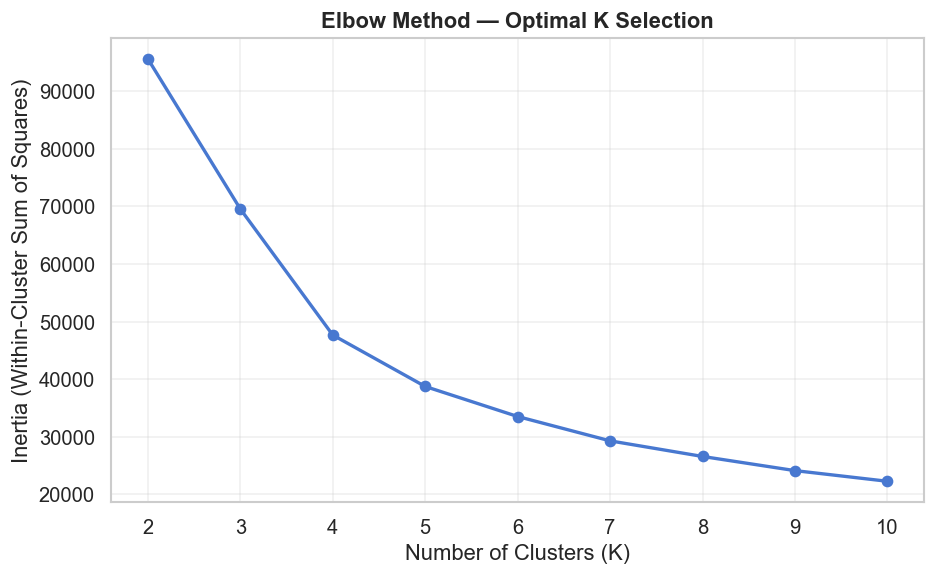

In [16]:

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method — Optimal K Selection', fontweight='bold')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The elbow appears around **K = 3**, suggesting three natural segments in the data.

In [17]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster sizes:')
print(cluster_df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    12968
1    29330
2     3625
Name: count, dtype: int64


In [18]:

summary = cluster_df.groupby('Cluster')[cluster_features].agg(['mean', 'median']).round(2)
summary

price        availability_365        number_of_reviews       
           mean median             mean median              mean median
Cluster                                                                
0        131.68  115.0           284.31  307.0             17.07    7.0
1        115.34  100.0            24.29    0.0             11.32    4.0
2        115.56  100.0           172.02  178.0            150.67  132.0

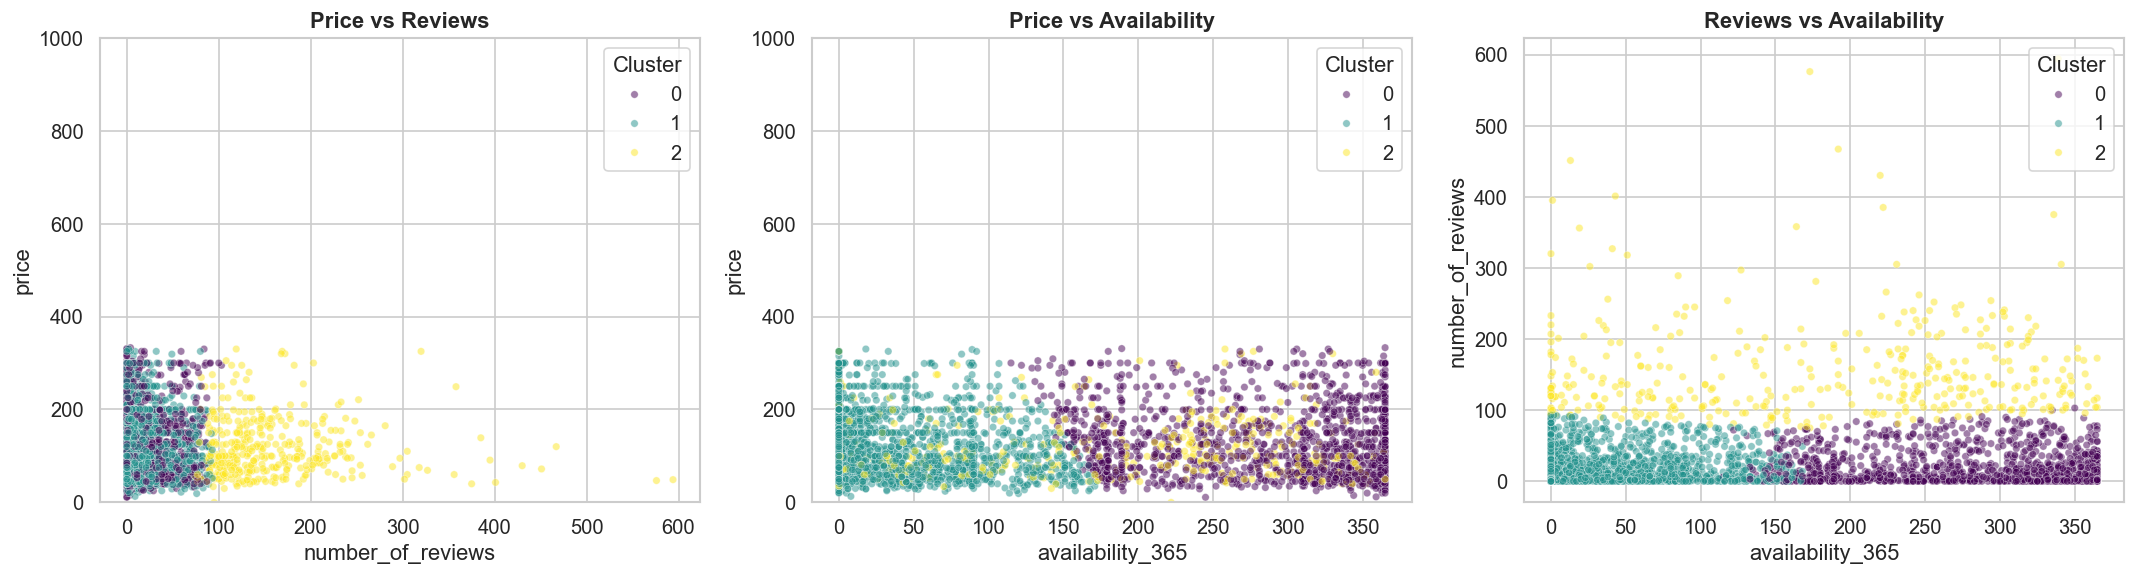

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price vs Reviews
scatter_sample = cluster_df.sample(5000, random_state=42)

sns.scatterplot(data=scatter_sample, x='number_of_reviews', y='price',
                hue='Cluster', palette='viridis', alpha=0.5, s=20, ax=axes[0])
axes[0].set_title('Price vs Reviews', fontweight='bold')
axes[0].set_ylim(0, 1000)

# Price vs Availability
sns.scatterplot(data=scatter_sample, x='availability_365', y='price',
                hue='Cluster', palette='viridis', alpha=0.5, s=20, ax=axes[1])
axes[1].set_title('Price vs Availability', fontweight='bold')
axes[1].set_ylim(0, 1000)

# Reviews vs Availability
sns.scatterplot(data=scatter_sample, x='availability_365', y='number_of_reviews',
                hue='Cluster', palette='viridis', alpha=0.5, s=20, ax=axes[2])
axes[2].set_title('Reviews vs Availability', fontweight='bold')

plt.tight_layout()
plt.show()

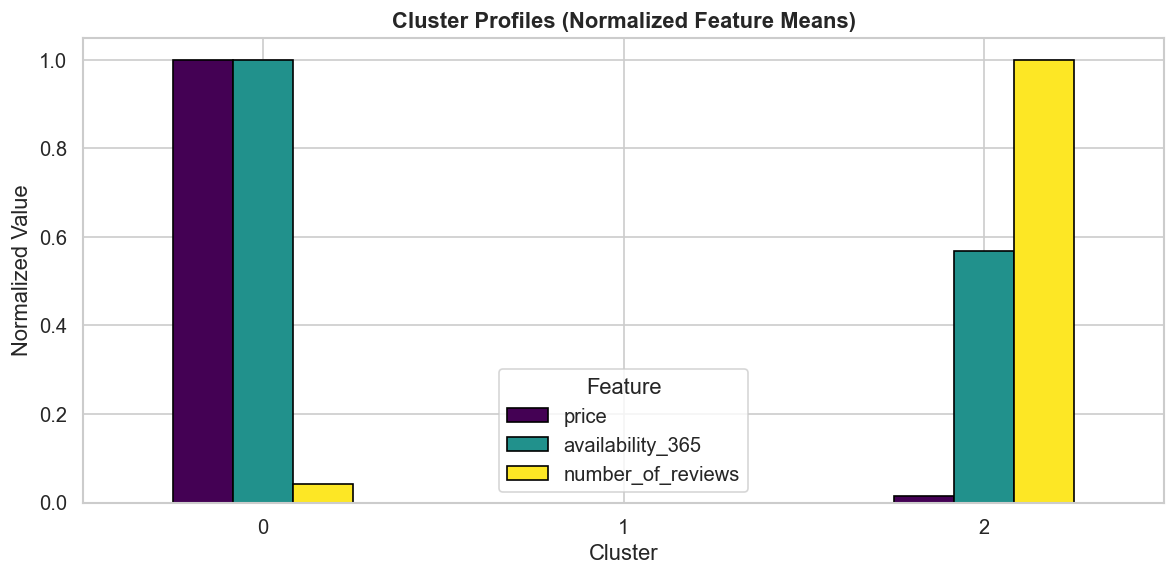

In [20]:
# ── Cluster Profile Bar Chart ──
cluster_means = cluster_df.groupby('Cluster')[cluster_features].mean()

# Normalize for comparison
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

cluster_norm.plot(kind='bar', figsize=(10, 5), colormap='viridis', edgecolor='black')
plt.title('Cluster Profiles (Normalized Feature Means)', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Normalized Value')
plt.legend(title='Feature')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 📝 Cluster Interpretation

| Cluster | Profile | Description |
|---------|---------|-------------|
| 0 | **Budget / High-Demand** | Low price, moderate-to-high reviews, lower availability — popular budget listings that book up fast |
| 1 | **Premium / Low-Demand** | High price, few reviews, variable availability — luxury or overpriced listings with fewer bookings |
| 2 | **Moderate / Steady** | Mid-range price, high availability, moderate reviews — well-balanced listings for average travellers |

> *Note: Exact cluster assignments may vary based on the data distribution. Refer to the summary table above for precise values.*

---
## 🔹 Step 4: Final Statistical Insights

Below are **8 key statistical findings** from this analysis:

1. **Room type significantly affects pricing (p < 0.05)** — ANOVA confirms that entire homes, private rooms, and shared rooms occupy distinct price tiers.

2. **Manhattan commands a statistically significant price premium** — the t-test shows Manhattan's mean price is substantially higher than the combined average of other boroughs.

3. **Reviews and availability have a weak but significant correlation** — popular listings do not necessarily remain highly available, suggesting rapid booking turnover.

4. **Numerical features alone are poor predictors of price** — the low R² score from linear regression confirms that categorical factors (room type, location) dominate pricing.

5. **Minimum nights has a small positive coefficient** — listings requiring longer stays tend to have marginally higher prices (corporate/long-term rental effect).

6. **Three distinct market segments exist** — KMeans clustering reveals Budget/High-Demand, Premium/Low-Demand, and Moderate/Steady segments.

7. **Budget listings form the largest cluster** — the majority of NYC Airbnb listings are affordable and experience high booking volumes.

8. **Premium listings are few but overpriced relative to demand** — high prices combined with low review counts suggest that many luxury listings are either niche or overpriced.

---
*Notebook prepared by Section A — Group 18 | Airbnb NYC Analysis Project*